In [1]:
## **課題１**

# 授業中に紹介したSKABデータについてXGBoostを用いてモデル構築を行い，
# RandomForestの変数重要度，SHAP値と比較してどのような違いがあるか検証を行え．
# また，可能であればSVMなど他の予測モデルで予測を行った結果と比較を行い，
# 予測に効く変数が検討したモデルでどのように異なるか考察を行え．

## **課題２**

# 自分の興味のあるデータ（対象は何でも良いが回帰の問題をおすすめする：SHAPバージョンによるトラブルを避けるため）について今回と同様のRandomForestやSHAP値による解析を行い，
# 対象のデータの予測に効く変数がどのようなものか，またそこからどのようなことが考察できるのか（どのような現象が発生しているか？など）について考察を行え

In [2]:
%pip install xgboost
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.inspection import permutation_importance

from sklearn.tree import DecisionTreeClassifier, export_graphviz

import graphviz

c:\Users\yuema\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# データの読み込み
df = pd.read_csv('data/valve1.csv',)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Accelerometer1RMS,18160.0,0.027338,0.000527,0.025553,0.026971,0.027346,0.027722,0.029031
Accelerometer2RMS,18160.0,0.040546,0.001168,0.037339,0.039761,0.040461,0.041192,0.053439
Current,18160.0,0.974279,0.273464,0.355411,0.739579,0.986835,1.202650,1.662610
Pressure,18160.0,0.063758,0.258584,-1.257000,0.054711,0.054711,0.054711,1.694350
Temperature,18160.0,70.207720,2.608980,65.188700,68.630525,69.765300,71.075925,79.889100
Thermocouple,18160.0,25.029108,0.447720,24.418700,24.674200,24.866800,25.423625,26.104400
Voltage,18160.0,230.710674,10.817408,203.135000,224.785750,230.959000,236.880500,255.324000
Volume Flow RateRMS,18160.0,31.284849,1.991965,22.000000,31.001000,32.000000,32.012600,33.969400
anomaly,18160.0,0.347412,0.476161,0.000000,0.000000,0.000000,1.000000,1.000000
changepoint,18160.0,0.003469,0.058799,0.000000,0.000000,0.000000,0.000000,1.000000


In [5]:
# 欠損値の確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18160 entries, 0 to 18159
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             18160 non-null  object 
 1   Accelerometer1RMS    18160 non-null  float64
 2   Accelerometer2RMS    18160 non-null  float64
 3   Current              18160 non-null  float64
 4   Pressure             18160 non-null  float64
 5   Temperature          18160 non-null  float64
 6   Thermocouple         18160 non-null  float64
 7   Voltage              18160 non-null  float64
 8   Volume Flow RateRMS  18160 non-null  float64
 9   anomaly              18160 non-null  float64
 10  changepoint          18160 non-null  float64
dtypes: float64(10), object(1)
memory usage: 1.5+ MB


In [6]:
df = df.drop(["datetime", "changepoint"], axis=1)
df

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly
0,0.026588,0.040111,1.330200,0.054711,79.3366,26.0199,233.062,32.0000,0.0
1,0.026170,0.040453,1.353990,0.382638,79.5158,26.0258,236.040,32.0000,0.0
2,0.026199,0.039419,1.540060,0.710565,79.3756,26.0265,251.380,32.0000,0.0
3,0.026027,0.039641,1.334580,0.382638,79.6097,26.0393,234.392,32.0000,0.0
4,0.026290,0.040273,1.078510,-0.273216,79.6109,26.0420,225.342,32.0000,0.0
...,...,...,...,...,...,...,...,...,...
18155,0.027605,0.039760,0.622996,0.382638,68.4247,24.4370,230.358,32.9673,0.0
18156,0.027286,0.039613,0.600692,0.054711,68.0598,24.4356,231.373,32.0000,0.0
18157,0.027203,0.041440,0.450323,0.054711,68.1836,24.4379,210.605,32.0337,0.0
18158,0.027180,0.041831,0.855527,0.382638,68.2250,24.4310,229.566,32.9673,0.0


In [7]:
# 説明変数と目的変数の分割
df_x = df.drop('anomaly', axis=1)
df_y = df.anomaly

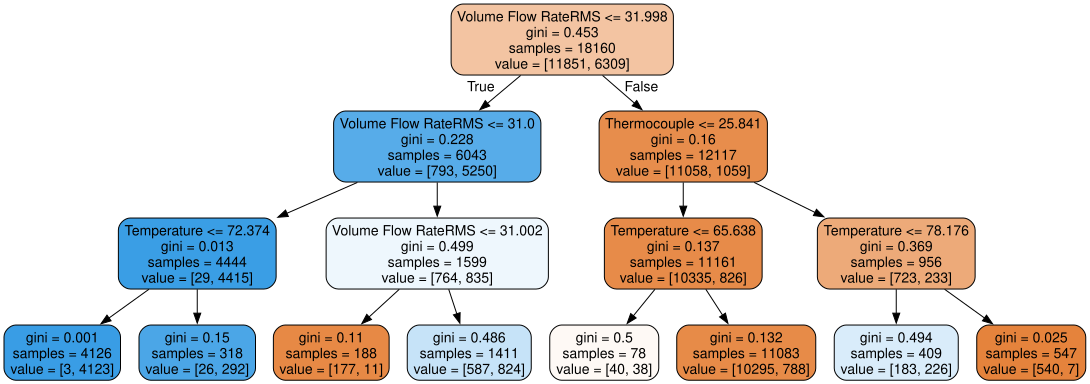

In [8]:
# 決定木を学習させる
clf = DecisionTreeClassifier(random_state=0, max_depth=3)
clf = clf.fit(df_x, df_y)

# 学習結果を出力
display(graphviz.Source(export_graphviz(clf, feature_names=df_x.columns, impurity=True, filled=True, rounded=True)))

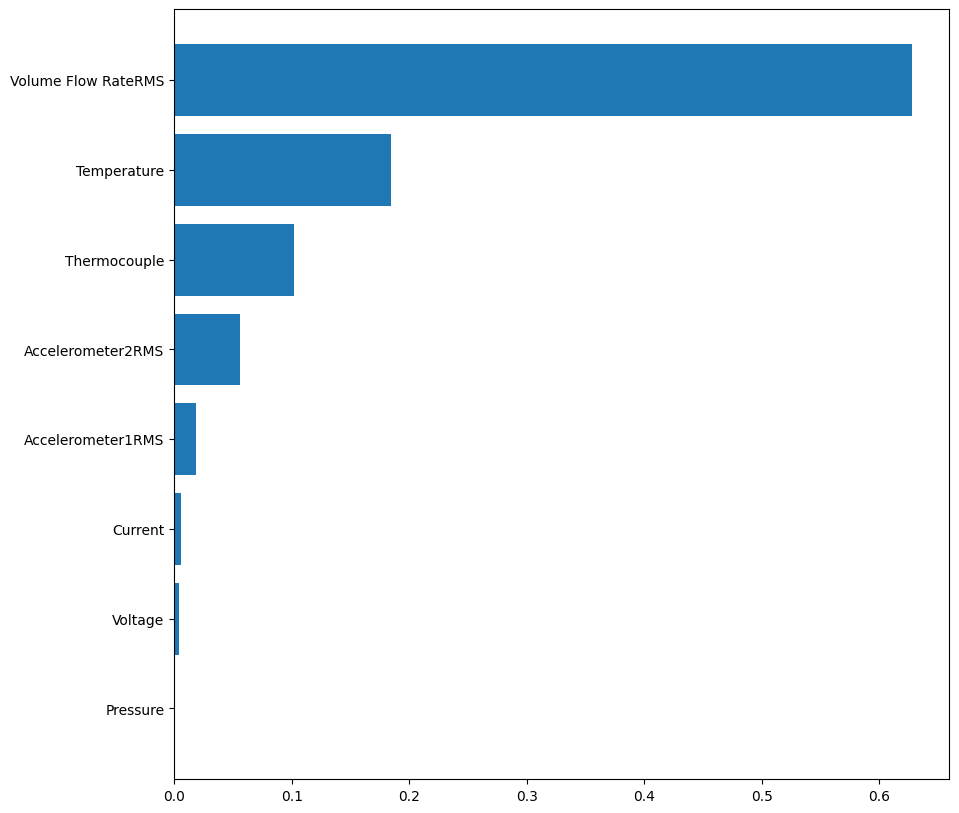

In [9]:
# 変数重要度の算出
# ランダムフォレストを学習させる
clf2 = RandomForestClassifier(random_state=0, max_depth=3, n_estimators=150)
clf2 = clf2.fit(df_x, df_y)

# 変数の重要度の確認
features = df_x.columns                     # 説明変数の名前を取得
importances = clf2.feature_importances_     # 変数重要度を取得
indices = np.argsort(importances)           # 変数重要度をソートした際のインデックスを取得    

# プロット
plt.figure(figsize=(10,10))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.show()

In [10]:
# ランダムフォレストによる分類木
# テストデータの分割
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.3, random_state=0)

# ランダムフォレストを学習させる
clf3 = RandomForestClassifier(random_state=0, max_depth=3, n_estimators=150)
clf3 = clf3.fit(X_train, y_train)

# 構築したランダムフォレストの学習器で予測を行う
pred = clf3.predict(X_test)

# 予測精度を評価するF値の確認
mat = confusion_matrix(y_test, pred)
# pdで表形式に
conf_df = pd.DataFrame(mat)
print(conf_df)

print("-------------------")
print("F1スコアを確認する")
print(f1_score(y_test, pred, average='macro'))

      0     1
0  3497    15
1   497  1439
-------------------
F1スコアを確認する
0.8903777273166718


In [11]:
# 勾配ブースティング
dtrain = xgb.DMatrix(X_train, label=y_train)

#Xgboostのパラメータを設定する．ここでは…
#max_depth: 木構造の最大の深さ
#eta: 学習効率
#objective: 学習の目的
#reg: linear(線形回帰)
#reg: logistic(ロジスティック回帰)
#binary: logistic(2値分類)
#multi: softmax(多値分類（2値でも可能）)
#num_class: クラス数（'objective': 'multi:softmax'の時に必要）

xgb_params = {
    'max_depth': 3,
    'eta': 0.1,
    'objective': 'multi:softmax',
    'num_class': 2
}
# 学習を実行する
gbm = xgb.train(xgb_params, dtrain, num_boost_round=1000)
# テストデータをDMatrixに変換
dtest = xgb.DMatrix(X_test)
# 予測を実行
pred2 = gbm.predict(dtest)
# 混合行列で精度を確認
mat2 = confusion_matrix(y_test, pred2)
conf_df2 = pd.DataFrame(mat2)
print(conf_df2)

print("-------------------")
print("F1スコアを確認する")
print(f1_score(y_test, pred2, average='macro'))

      0     1
0  3467    45
1   205  1731
-------------------
F1スコアを確認する
0.948925653751632


In [12]:
# モデルチューニング
# スコアの設定
ms = 0

#グリッドサーチのパラメータ設定
#n_estimators: 決定木の本数
#criterion: 多様性指標
#max_depth: 木の深さ

myparams = {RandomForestClassifier(): {"n_estimators": [i for i in range(1, 10)],
                                        "criterion": ["gini", "entropy"],
                                        "max_depth": [i for i in range(1, 5)]}}

# グリッドサーチによる探索
for model, params in myparams.items():
    #パラメータを振って当てはめ江
    SKAB_clf4 = GridSearchCV(model, params)
    SKAB_clf4.fit(X_train, y_train)
    #予測と予測精度確認
    pred = SKAB_clf4.predict(X_test)
    sc = f1_score(y_test, pred, average="micro")
    #これまでのスコアより新しいのが優れていたら更新する
    if ms < sc:
        ms = sc
        best_param = SKAB_clf4.best_params_
        best_model = model.__class__.__name__

print(ms)
print(best_model)
print(best_param)

0.8959251101321586
RandomForestClassifier
{'criterion': 'gini', 'max_depth': 4, 'n_estimators': 8}


In [13]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 1, 10)
    n_estimators =  trial.suggest_int('n_estimators', 1, 1000)
    SKAB_clf5 = RandomForestClassifier(max_depth = max_depth, n_estimators = n_estimators, n_jobs=4)
    score = cross_val_score(SKAB_clf5, X_train, y_train, cv=5, scoring="f1_macro")
    mean = score.mean()
    print(mean)
    return(mean)

#optunaで学習
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# チューニングしたハイパーパラメーターをフィット
optimised_rf = RandomForestClassifier(max_depth = study.best_params['max_depth'],
                                     n_estimators = study.best_params['n_estimators'],
                                     n_jobs=2)

optimised_rf.fit(X_train, y_train)

[I 2025-12-03 03:11:21,066] A new study created in memory with name: no-name-d27d8049-0ffa-4f62-9dc1-af657658aed9
[I 2025-12-03 03:11:23,296] Trial 0 finished with value: 0.9250657130087646 and parameters: {'max_depth': 7, 'n_estimators': 116}. Best is trial 0 with value: 0.9250657130087646.


0.9250657130087646


[I 2025-12-03 03:11:34,171] Trial 1 finished with value: 0.9328720496568312 and parameters: {'max_depth': 9, 'n_estimators': 516}. Best is trial 1 with value: 0.9328720496568312.


0.9328720496568312


[I 2025-12-03 03:11:39,376] Trial 2 finished with value: 0.9096838124729526 and parameters: {'max_depth': 5, 'n_estimators': 307}. Best is trial 1 with value: 0.9328720496568312.


...

[I 2025-12-03 03:12:43,364] Trial 8 finished with value: 0.9294134026195746 and parameters: {'max_depth': 8, 'n_estimators': 416}. Best is trial 3 with value: 0.9329950234385249.


0.9294134026195746


[I 2025-12-03 03:13:02,439] Trial 9 finished with value: 0.9353907936396141 and parameters: {'max_depth': 10, 'n_estimators': 734}. Best is trial 9 with value: 0.9353907936396141.


0.9353907936396141


,n_estimators,734
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
pred = optimised_rf.predict(X_test)
#混合行列のための関数を読み込む
from sklearn.metrics import confusion_matrix
#混合行列で精度を確認する
mat = confusion_matrix(y_test, pred)
#pandasで表の形に
conf_df = pd.DataFrame(mat)
print(conf_df)

#F1スコアを確認する
from sklearn.metrics import f1_score
print(f1_score(y_test, pred, average="macro"))

      0     1
0  3484    28
1   312  1624
0.9293576654895995


In [ ]:
# Geminiの回答を記載
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import shap

In [ ]:
# 日本語フォントの設定（環境に合わせて調整が必要な場合があります）
# Colab環境等で日本語表示が難しい場合は英語表記のままにします。

# 1. データの読み込みと前処理
url = 'data/valve1.csv'
df = pd.read_csv(url, sep=",")

# 不要な列の削除
df_clean = df.drop(["datetime", "changepoint"], axis=1)

# 説明変数と目的変数の分離
X = df_clean.drop('anomaly', axis=1)
y = df_clean['anomaly']

# データの分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# SVM用にデータの標準化（スケーリング）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 2. モデルの構築と学習

# XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=42, max_depth=5) # 深さを制限して過学習抑制
rf_model.fit(X_train, y_train)

# SVM (RBFカーネルを使用)
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 3. モデルの評価 (F1 Score - Macro)
xgb_pred = xgb_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test_scaled)

print(f"XGBoost F1 Score: {f1_score(y_test, xgb_pred, average='macro'):.4f}")
print(f"Random Forest F1 Score: {f1_score(y_test, rf_pred, average='macro'):.4f}")
print(f"SVM F1 Score: {f1_score(y_test, svm_pred, average='macro'):.4f}")

# 4. 変数重要度の取得とSHAP値の計算

# --- 変数重要度 (Gini / Permutation) ---
# XGBoost Feature Importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# Random Forest Feature Importance
rf_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

# SVM Permutation Importance
# SVMはfeature_importances_を持たないため、Permutation Importanceを使用
perm_importance = permutation_importance(svm_model, X_test_scaled, y_test, n_repeats=10, random_state=42)
svm_imp = pd.Series(perm_importance.importances_mean, index=X.columns).sort_values(ascending=True)

# --- SHAP値 ---
# XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Random Forest
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)
# RFのSHAPはクラスごとのリストで返るため、異常クラス(1)側を取得
if isinstance(shap_values_rf, list):
    shap_values_rf = shap_values_rf[1]

# SVM (KernelExplainerを使用 - 計算コストが高いためデータの一部を使用)
# 背景データとして訓練データの一部（kmeansで要約）を使用
X_train_summary = shap.kmeans(X_train_scaled, 10)
explainer_svm = shap.KernelExplainer(svm_model.predict, X_train_summary)
shap_values_svm = explainer_svm.shap_values(X_test_scaled)


# 5. 可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xgb_imp.plot(kind='barh', ax=axes[0], title='XGBoost Feature Importance')
rf_imp.plot(kind='barh', ax=axes[1], title='Random Forest Feature Importance')
svm_imp.plot(kind='barh', ax=axes[2], title='SVM Permutation Importance')

plt.tight_layout()
plt.show()

# SHAP Summary Plots
print("XGBoost SHAP Summary")
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")
print("Random Forest SHAP Summary")
shap.summary_plot(shap_values_rf, X_test, plot_type="bar")
print("SVM SHAP Summary")
shap.summary_plot(shap_values_svm, X_test_scaled_df, plot_type="bar")

c:\Users\yuema\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [03:26:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost F1 Score: 0.9521
Random Forest F1 Score: 0.9031
SVM F1 Score: 0.8807
